In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ler.lens_galaxy_population import LensGalaxyParameterDistribution

## data generation

In [5]:
ler_sie = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    directory="../interpolator_json",
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [6]:
# stronly lensed 
lens_params = ler_sie.sample_lens_parameters(50000)

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [7]:
# image properties
lens_params_ext = ler_sie.image_properties_function(lens_parameters=lens_params)
lens_params_ext.keys()

computing image properties using ler's epl+shear (analytical, njit) solver...


dict_keys(['zl', 'zs', 'sigma', 'q', 'phi', 'gamma', 'gamma1', 'gamma2', 'mass_1_source', 'mass_ratio', 'mass_2_source', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'a_1', 'a_2', 'luminosity_distance', 'mass_1', 'mass_2', 'x0_image_positions', 'x1_image_positions', 'magnifications', 'time_delays', 'image_type', 'n_images', 'x_source', 'y_source'])

## Check Magnification

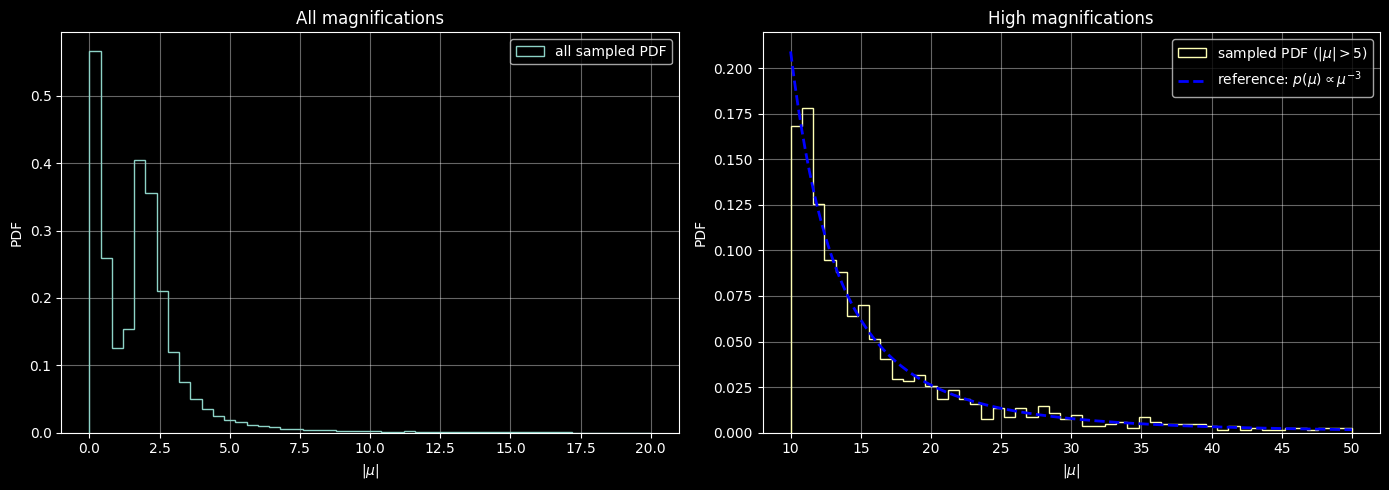

In [8]:
# two-panel plot: all |mu| and high-magnification tail (|mu| > 5)
mu = np.abs(lens_params_ext["magnifications"])
mu_vals = mu[np.isfinite(mu) & (mu > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) all magnifications
axes[0].hist(
    mu_vals,
    bins=50,
    range=(0, 20),
    density=True,
    histtype="step",
    color="C0",
    label="all sampled PDF",
)
axes[0].set_xlabel(r"$|\mu|$")
axes[0].set_ylabel("PDF")
axes[0].set_title("All magnifications")
axes[0].grid(alpha=0.4)
axes[0].legend()

# 2) high magnifications only: |mu| > 10
mu_cut = 10
mu_hi = mu_vals[mu_vals > mu_cut]
hist_hi, edges_hi, _ = axes[1].hist(
    mu_hi,
    bins=50,
    range=(mu_cut, 50),
    density=True,
    histtype="step",
    color="C1",
    label=r"sampled PDF ($|\mu|>5$)",
)

centers_hi = 0.5 * (edges_hi[:-1] + edges_hi[1:])
tail_mask = hist_hi > 0
if np.any(tail_mask):
    A = np.median(hist_hi[tail_mask] * centers_hi[tail_mask] ** 3)
    mu_line = np.linspace(10, 50, 300)
    axes[1].plot(
        mu_line,
        A * mu_line**(-3),
        "b--",
        lw=2,
        label=r"reference: $p(\mu)\propto \mu^{-3}$",
    )

axes[1].set_xlabel(r"$|\mu|$")
axes[1].set_ylabel("PDF")
axes[1].set_title("High magnifications")
axes[1].grid(alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

## Get Pdet

In [10]:
# for detectable lensed events
from gwsnr import GWSNR
snr_fn = GWSNR(npool=6)

Extracting interpolator data from /Users/phurailatpamhemantakumar/phd/mypackages/gwsnr/gwsnr/core/core_data/interpolator_json.zip to the current working directory.

Initializing GWSNR class...

psds not given. Choosing bilby's default psds
Interpolator will be loaded for L1 detector from ./interpolator_json/L1/partialSNR_dict_0.json
Interpolator will be loaded for H1 detector from ./interpolator_json/H1/partialSNR_dict_0.json
Interpolator will be loaded for V1 detector from ./interpolator_json/V1/partialSNR_dict_0.json

Chosen GWSNR initialization parameters:

npool:  6
snr type:  interpolation_aligned_spins
waveform approximant:  IMRPhenomD
sampling frequency:  2048.0
minimum frequency (fmin):  20.0
reference frequency (f_ref):  20.0
mtot=mass1+mass2
min(mtot):  9.96
max(mtot) (with the given fmin=20.0): 235.0
detectors:  ['L1', 'H1', 'V1']
psds:  [[array([  10.21659,   10.23975,   10.26296, ..., 4972.81   ,
       4984.081  , 4995.378  ], shape=(2736,)), array([4.43925574e-41, 4.2277

In [11]:
result_dict, lensed_param_ext_det = ler_sie.get_lensed_snrs(
    lensed_param=lens_params_ext,
    pdet_finder=snr_fn.pdet,
    include_effective_parameters=False,
)

In [12]:
dict_ = dict(
    pdet_net=result_dict["pdet_net"],
)
lensed_param_ext_det.update(dict_)
# recover the redundant parameters
# otherwise set include_effective_parameters to True in get_lensed_snrs
lensed_param_ext_det = ler_sie.recover_redundant_parameters(lensed_param_ext_det)

lensed_param_ext_all = lensed_param_ext_det.copy()
all_events_mask = np.array(~np.isnan(result_dict["pdet_net"]), dtype=float)
dict_ = dict(
    pdet_net=all_events_mask,
)
lensed_param_ext_all.update(dict_)

## Plot based on morse phase

In [13]:
from ler.utils import relative_mu_dt_lensed, mu_vs_dt_plot

morse_phase_det = relative_mu_dt_lensed(
    lensed_param=lensed_param_ext_det,
    classification_type='morse_phase'
)

morse_phase_all = relative_mu_dt_lensed(
    lensed_param=lensed_param_ext_all,
    classification_type='morse_phase'
)

In [14]:
morse_phase_det.keys(), morse_phase_det['dt_rel0'].shape, morse_phase_det['mu_rel0'].shape, morse_phase_det['dt_rel90'].shape[0], morse_phase_det['mu_rel90'].shape[0]

(dict_keys(['dt_rel0', 'mu_rel0', 'dt_rel90', 'mu_rel90']),
 (17,),
 (17,),
 72,
 72)

In [17]:
# in all events
# find number of 2, 3 4 image systems.
for n_images in [2, 3, 4]:
    print(f"Number of {n_images} image systems: {np.sum(lensed_param_ext_all['n_images'] == n_images)}, {np.sum(lensed_param_ext_all['n_images'] == n_images)/len(lensed_param_ext_all['n_images'])*100:.2f}%")

Number of 2 image systems: 44554, 89.11%
Number of 3 image systems: 53, 0.11%
Number of 4 image systems: 2201, 4.40%


In [21]:
# in detectable events
# find number of 2, 3 4 image systems.
num_det = np.sum(np.nan_to_num(lensed_param_ext_det['pdet_net']), axis=1)
for n_images in [2, 3, 4]:
    print(f"Number of {n_images} image systems: {np.sum(num_det == n_images)}, {np.sum( num_det == n_images)/np.sum(num_det >= 2)*100:.2f}%")

Number of 2 image systems: 47, 81.03%
Number of 3 image systems: 8, 13.79%
Number of 4 image systems: 3, 5.17%


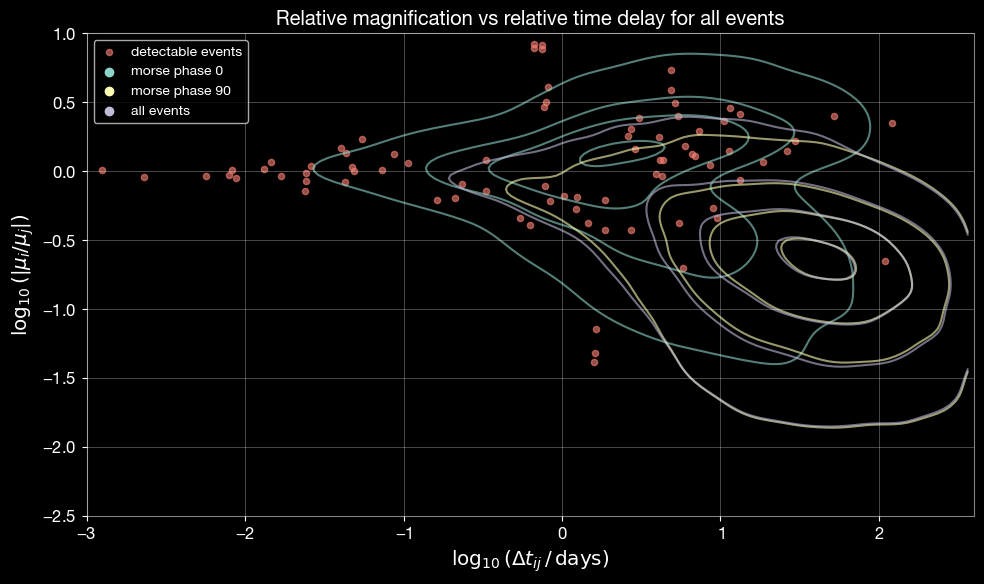

In [22]:
plt.figure(figsize=(10, 6))
# morse phase 0 and 90
mu_vs_dt_plot(
    x_array=morse_phase_all['dt_rel0'],
    y_array=morse_phase_all['mu_rel0'],
    colors=['C0']*5,
)
mu_vs_dt_plot(
    x_array=morse_phase_all['dt_rel90'],
    y_array=morse_phase_all['mu_rel90'],
    colors=['C1']*5,
)
# concatenate the two arrays
mu_vs_dt_plot(
    x_array=np.concatenate([morse_phase_all['dt_rel0'], morse_phase_all['dt_rel90']]),
    y_array=np.concatenate([morse_phase_all['mu_rel0'], morse_phase_all['mu_rel90']]),
    colors=['C2']*5,
)

# plot detectable events as scatter points
x_=np.concatenate([morse_phase_det['dt_rel0'], morse_phase_det['dt_rel90']])
x_ = np.log10(x_)
y_=np.concatenate([morse_phase_det['mu_rel0'], morse_phase_det['mu_rel90']])
y_ = np.log10(y_)
plt.scatter(
    x=x_,
    y=y_,
    color='C3',
    alpha=0.6,
    s=20,
    label='detectable events'
)

# add legend
# add legend (proxy artists)
plt.scatter([], [], color='C0', label='morse phase 0')
plt.scatter([], [], color='C1', label='morse phase 90')
plt.scatter([], [], color='C2', label='all events')
legend = plt.legend(
    handlelength=1.5,
    loc='upper left',
    bbox_to_anchor=(0, 1),
    frameon=True,
    fontsize=10,
    edgecolor='lightgray'
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.6)
    handle.set_alpha(0.85)

plt.xlabel(r'$\log_{10}(\Delta t_{ij} \,/\, \mathrm{days})$')
plt.ylabel(r'$\log_{10}(|\mu_i / \mu_j|)$')
plt.xlim(-3.0, 2.6)
plt.ylim(-2.5, 1)

plt.grid(alpha=0.4)
plt.title('Relative magnification vs relative time delay for all events')
plt.tight_layout()
plt.show()

## Plot based on arival time

In [23]:
arrival_time_det = relative_mu_dt_lensed(
    lensed_param=lensed_param_ext_det,
    classification_type='arrival_time'
)

arrival_time_all = relative_mu_dt_lensed(
    lensed_param=lensed_param_ext_all,
    classification_type='arrival_time'
)

classification_type = arrival_time
make sure that the images are sorted wrt to arrival time
direct output from "ler" should be sorted
classification_type = arrival_time
make sure that the images are sorted wrt to arrival time
direct output from "ler" should be sorted


In [24]:
arrival_time_det.keys()

dict_keys(['dt_12', 'mu_12', 'dt_13', 'mu_13', 'dt_14', 'mu_14', 'dt_23', 'mu_23', 'dt_24', 'mu_24', 'dt_34', 'mu_34'])

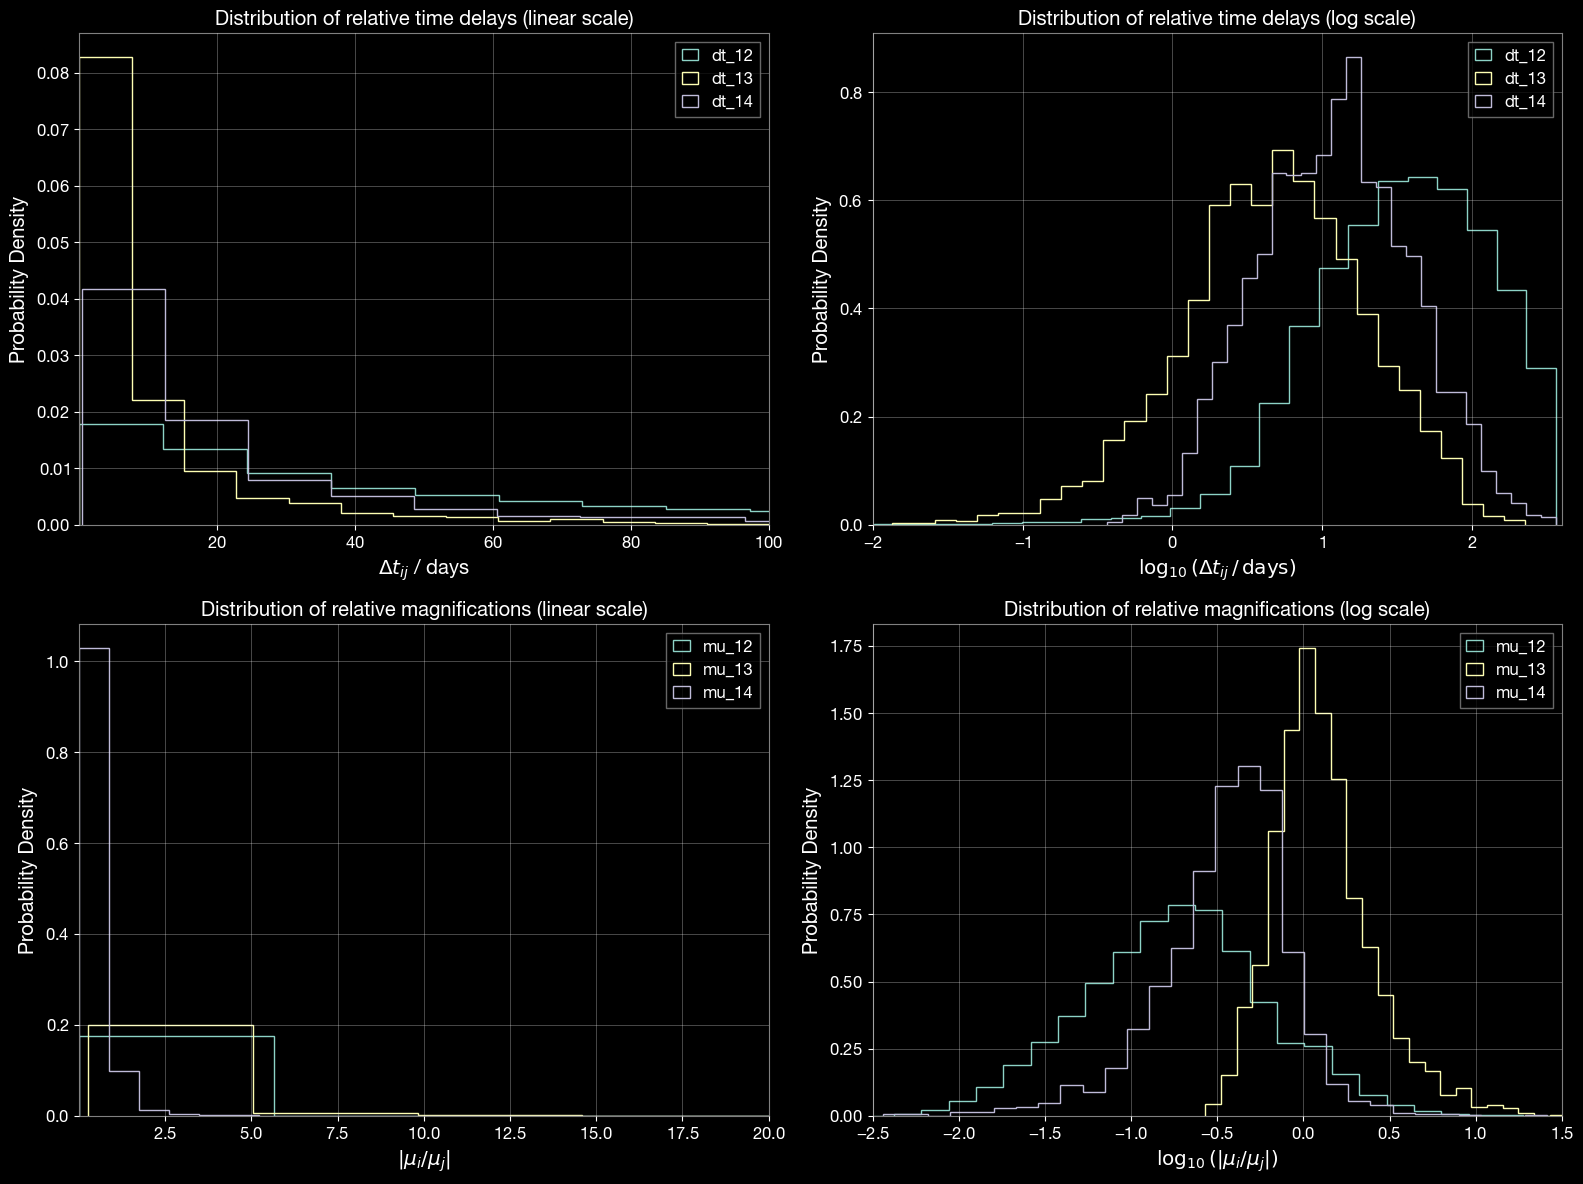

In [25]:
# 2x2 plot: top row - time delay distributions, bottom row - magnification distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

dt_keys = ['dt_12', 'dt_13', 'dt_14']
mu_keys = ['mu_12', 'mu_13', 'mu_14']
colors = ['C0', 'C1', 'C2']

# Top left: time delay linear scale
for key, color in zip(dt_keys, colors):
    axes[0, 0].hist(
        arrival_time_all[key],
        bins=30,
        density=True,
        histtype='step',
        color=color,
        label=key,
    )
axes[0, 0].set_xlabel(r'$\Delta t_{ij}$ / days')
axes[0, 0].set_ylabel('Probability Density')
axes[0, 0].set_title('Distribution of relative time delays (linear scale)')
axes[0, 0].legend()
axes[0, 0].set_xlim(0.01, 100)
axes[0, 0].grid(alpha=0.4)

# Top right: time delay log scale
for key, color in zip(dt_keys, colors):
    axes[0, 1].hist(
        np.log10(arrival_time_all[key]),
        bins=30,
        density=True,
        histtype='step',
        color=color,
        label=key,
    )
axes[0, 1].set_xlabel(r'$\log_{10}(\Delta t_{ij} \,/\, \mathrm{days})$')
axes[0, 1].set_ylabel('Probability Density')
axes[0, 1].set_title('Distribution of relative time delays (log scale)')
axes[0, 1].legend()
axes[0, 1].set_xlim(-2, 2.6)
axes[0, 1].grid(alpha=0.4)

# Bottom left: magnification linear scale
for key, color in zip(mu_keys, colors):
    axes[1, 0].hist(
        arrival_time_all[key],
        bins=30,
        density=True,
        histtype='step',
        color=color,
        label=key,
    )
axes[1, 0].set_xlabel(r'$|\mu_i / \mu_j|$')
axes[1, 0].set_ylabel('Probability Density')
axes[1, 0].set_title('Distribution of relative magnifications (linear scale)')
axes[1, 0].legend()
axes[1, 0].set_xlim(0.01, 20)
axes[1, 0].grid(alpha=0.4)

# Bottom right: magnification log scale
for key, color in zip(mu_keys, colors):
    axes[1, 1].hist(
        np.log10(arrival_time_all[key]),
        bins=30,
        density=True,
        histtype='step',
        color=color,
        label=key,
    )
axes[1, 1].set_xlabel(r'$\log_{10}(|\mu_i / \mu_j|)$')
axes[1, 1].set_ylabel('Probability Density')
axes[1, 1].set_title('Distribution of relative magnifications (log scale)')
axes[1, 1].legend()
axes[1, 1].set_xlim(-2.5, 1.5)
axes[1, 1].grid(alpha=0.4)

plt.tight_layout()
plt.show()